# India Air Quality Analysis (PM2.5) — 2021-2023

This project analyzes PM2.5 pollution trends across Indian states using real
monitoring station data, state demographic data, and NCAP government funding
data. It explores which states are most polluted, how pollution varies
seasonally and by weekday/weekend, and whether NCAP funding correlates with
improved air quality.

**Tools used:** Python, pandas, numpy, matplotlib, scikit-learn
**Data sources:** Station-level PM2.5 air quality data (CPCB monitoring network),
state population/area data (Census of India), and National Clean Air Programme
(NCAP) funding data — provided as part of an academic data analysis assignment.

In [21]:
from google.colab import files
uploaded = files.upload()

Saving NCAP_Funding.csv to NCAP_Funding (1).csv
Saving Data.csv to Data (2).csv
Saving State_data.csv to State_data (1).csv


In [75]:
import os
os.makedirs('outputs', exist_ok=True)

In [76]:
# ── SETUP:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Load datasets ──
df = pd.read_csv('Data.csv')
state_df = pd.read_csv('State_data.csv')
ncap_df = pd.read_csv('NCAP_Funding.csv')

# ── Parse dates ──
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%d-%m-%Y', errors='coerce')
df['Year']  = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek   # 0=Mon … 6=Sun

print('Data shape:', df.shape)
print('State_data shape:', state_df.shape)
print('NCAP_Funding shape:', ncap_df.shape)
df.head(3)

Data shape: (38664, 12)
State_data shape: (31, 3)
NCAP_Funding shape: (117, 8)


,Timestamp,Station,PM2.5,PM10,Address,City,Latitude,Longitude,State,Year,Month,DayOfWeek
0,2018-02-28,"32Bungalows, Bhilai - CECB",NaN,NaN,"Bhilai RO Office, 5, 32 Bungalows, Bhilai, Dis...",Bhilai,21.194815,81.314770,Chhattisgarh,2018,2,2
1,2018-02-28,"AIIMS, Raipur - CECB",NaN,NaN,"All India Institute Of Medical Science, Gate N...",Raipur,21.258815,81.578979,Chhattisgarh,2018,2,2
2,2018-02-28,"Adarsh Nagar, Jaipur - RSPCB",55.72936,182.28482,"Psychiatric Centre, Janta Colony, Govind Marg,...",Jaipur,26.902909,75.836858,Rajasthan,2018,2,2


In [77]:
print("Missing values per column:\n", df.isnull().sum())
print("\nRows with invalid/missing dates:", df['Timestamp'].isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("\nShape after cleaning:", df.shape)

Missing values per column:
 Timestamp        0
Station          0
PM2.5        19671
PM10         20398
Address       4392
City             0
Latitude         0
Longitude        0
State            0
Year             0
Month            0
DayOfWeek        0
dtype: int64

Rows with invalid/missing dates: 0

Duplicate rows: 0

Shape after cleaning: (38664, 12)


### 1. Most Polluted States (All-Time Average)
Identifying which states consistently record the highest PM2.5 levels helps
prioritize where air quality interventions are most urgently needed.

In [78]:
def state_avg_pm25(data, year=None, top_n=10, ascending=False):
    d = data[data['Year'] == year] if year else data
    result = d.groupby('State')['PM2.5'].mean().sort_values(ascending=ascending)
    return result.head(top_n)

In [79]:
state_avg = df.groupby('State')['PM2.5'].mean().sort_values(ascending=False)

print('=== Top 5 states by average PM2.5 (all years) ===')
print(state_avg.head(5).to_string())
print(f'\n>>> ANSWER: {state_avg.idxmax()} with {state_avg.max():.2f} µg/m³')



=== Top 5 states by average PM2.5 (all years) ===
State
Delhi            103.156803
Bihar             81.201424
Uttar Pradesh     74.932096
Haryana           72.855322
Jharkhand         63.060256

>>> ANSWER: Delhi with 103.16 µg/m³


### 2. States with the Most Hazardous Pollution Days (2023)
Days above 300 µg/m³ pose serious health risks. Counting these by state
highlights where acute pollution events are most frequent.

In [80]:
state_avg_pm25(df)                          # all-time top states

df23 = df[df['Year'] == 2023]
hazardous_days = (
    df23[df23['PM2.5'] > 300]
    .groupby('State')
    .size()
    .sort_values(ascending=False)
)

print('=== States by hazardous PM2.5 days (2023) ===')
print(hazardous_days.head(10).to_string())
print(f'\n>>> ANSWER: {hazardous_days.idxmax()} with {hazardous_days.max()} hazardous days')


=== States by hazardous PM2.5 days (2023) ===
State
Delhi          5
Bihar          1
Maharashtra    1

>>> ANSWER: Delhi with 5 hazardous days


### 3. Pollution Variability Across Stations (2023)
Beyond the average, understanding how much PM2.5 varies between stations
within a state reveals whether pollution is uniform or localized to hotspots.

In [81]:
# Step 1: mean PM2.5 per station in 2023
station_means_23 = df23.groupby(['State', 'Station'])['PM2.5'].mean()

# Step 2: std of those station means per state  (inter-station variability)
state_variability = station_means_23.groupby('State').std().sort_values(ascending=False)

print('=== Top 10 states by PM2.5 variability across stations (2023) ===')
print(state_variability.head(10).to_string())
print(f'\n>>> ANSWER: {state_variability.idxmax()} with std = {state_variability.max():.2f} µg/m³')


=== Top 10 states by PM2.5 variability across stations (2023) ===
State
Assam             39.407233
Bihar             34.069337
Manipur           29.626182
Tripura           23.761435
Uttar Pradesh     20.961211
Madhya Pradesh    20.632686
Delhi             20.064651
Haryana           19.576832
Odisha            19.334191
Jharkhand         17.420471

>>> ANSWER: Assam with std = 39.41 µg/m³


### 4. Cleanest States in the Post-COVID Period (2021-2022)
Comparing states with the lowest average PM2.5 during this period highlights
regions with consistently better air quality.

In [82]:
post_covid = df[df['Year'].isin([2021, 2022])]
post_covid_avg = state_avg_pm25(post_covid, ascending=True)
print('=== Bottom 10 states by average PM2.5 (Post-Covid 2021-2022) ===')
print(post_covid_avg.head(10).to_string())
print(f'\n>>> ANSWER: {post_covid_avg.idxmin()} with {post_covid_avg.min():.2f} µg/m³')


=== Bottom 10 states by average PM2.5 (Post-Covid 2021-2022) ===
State
Mizoram              11.150729
Sikkim               11.749827
Meghalaya            18.483756
Arunachal Pradesh    19.569502
Manipur              20.329441
Puducherry           23.047724
Karnataka            27.852924
Chhattisgarh         28.489123
Tamil Nadu           28.699848
Jammu and Kashmir    30.336258

>>> ANSWER: Mizoram with 11.15 µg/m³


### 5. Peak Pollution Event — August 2021
Pinpointing the single highest PM2.5 reading in a given month/year helps
identify extreme pollution spikes and their locations.


In [83]:
aug21 = df[(df['Year'] == 2021) & (df['Month'] == 8)]
max_idx = aug21['PM2.5'].idxmax()
row = aug21.loc[max_idx]

print(f">>> ANSWER: {row['Station']}")
print(f"    PM2.5 value : {row['PM2.5']:.2f} µg/m³")
print(f"    Date        : {row['Timestamp'].date()}")
print(f"    City/State  : {row['City']}, {row['State']}")

# Show the top-10 records in Aug 2021
print('\n=== Top 10 PM2.5 readings in August 2021 ===')
print(aug21.nlargest(10,'PM2.5')[['Timestamp','Station','City','State','PM2.5']].to_string(index=False))

>>> ANSWER: Anand Vihar, Delhi - DPCC
    PM2.5 value : 68.16 µg/m³
    Date        : 2021-08-31
    City/State  : Delhi, Delhi

=== Top 10 PM2.5 readings in August 2021 ===
 Timestamp                                      Station      City     State     PM2.5
2021-08-31                    Anand Vihar, Delhi - DPCC     Delhi     Delhi 68.158221
2021-08-31                            ITO, Delhi - CPCB     Delhi     Delhi 61.918157
2021-08-31                Sector-2 IMT, Manesar - HSPCB   Manesar   Haryana 58.120774
2021-08-31                Collectorate, Jodhpur - RSPCB   Jodhpur Rajasthan 57.731961
2021-08-31                 Sector 11, Faridabad - HSPCB Faridabad   Haryana 57.401203
2021-08-31         RIICO Ind. Area III, Bhiwadi - RSPCB   Bhiwadi Rajasthan 57.390659
2021-08-31 GIDC, Nandesari - Nandesari Ind. Association Nandesari   Gujarat 53.845205
2021-08-31                  Sector-51, Gurugram - HSPCB  Gurugram   Haryana 52.419825
2021-08-31                     Lodhi Road, Delhi - I

### 6. Seasonal Pollution Patterns — Kalaburagi Station (2022)
Breaking down PM2.5 by season at a specific station shows how weather
patterns (winter inversions, monsoon rain) drive pollution levels.

=== Seasonal avg PM2.5 at Kalaburagi (2022) ===
Season
Winter          52.458378
Summer          44.061560
Monsoon         12.977099
Post-Monsoon    49.963363

>>> Highest pollution season: Winter (52.46 µg/m³)


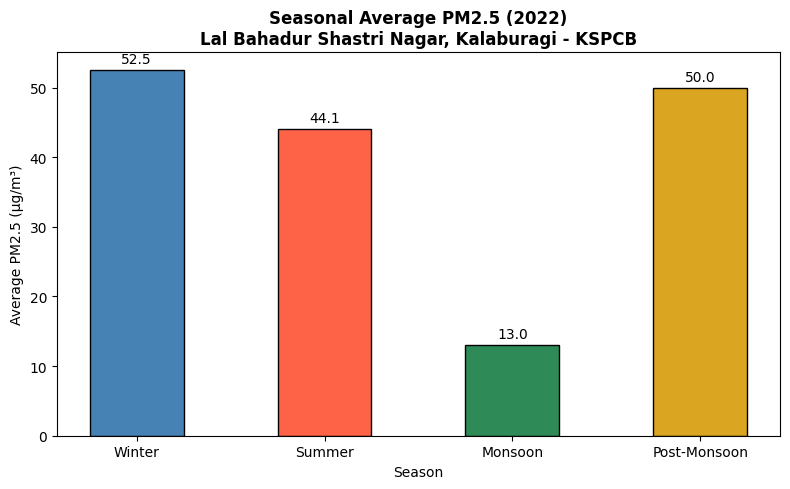

In [84]:
STATION = 'Lal Bahadur Shastri Nagar, Kalaburagi - KSPCB'

def assign_season(month):
    if month in [12, 1, 2]:  return 'Winter'
    if month in [3, 4, 5]:   return 'Summer'
    if month in [6, 7, 8, 9]:return 'Monsoon'
    return 'Post-Monsoon'      # Oct-Nov (not in scope, included for completeness)

ks22 = df[(df['Station'] == STATION) & (df['Year'] == 2022)].copy()
ks22['Season'] = ks22['Month'].apply(assign_season)

season_avg = ks22.groupby('Season')['PM2.5'].mean().reindex(['Winter','Summer','Monsoon','Post-Monsoon'])
print('=== Seasonal avg PM2.5 at Kalaburagi (2022) ===')
print(season_avg.to_string())
print(f'\n>>> Highest pollution season: {season_avg.idxmax()} ({season_avg.max():.2f} µg/m³)')

colors = ['steelblue','tomato','seagreen','goldenrod']
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(season_avg.index, season_avg.values, color=colors, edgecolor='k', width=0.5)
ax.bar_label(bars, fmt='%.1f', padding=3)
ax.set_title(f'Seasonal Average PM2.5 (2022)\n{STATION}', fontweight='bold')
ax.set_ylabel('Average PM2.5 (µg/m³)')
ax.set_xlabel('Season')
plt.tight_layout()
plt.savefig('outputs/seasonal_pm25_kalaburagi.png', dpi=150, bbox_inches='tight')
plt.show()

### 7. Weekday vs Weekend Pollution Trends — Kalaburagi (2021)
Comparing weekday and weekend PM2.5 levels helps assess how much traffic
and industrial activity contribute to pollution.

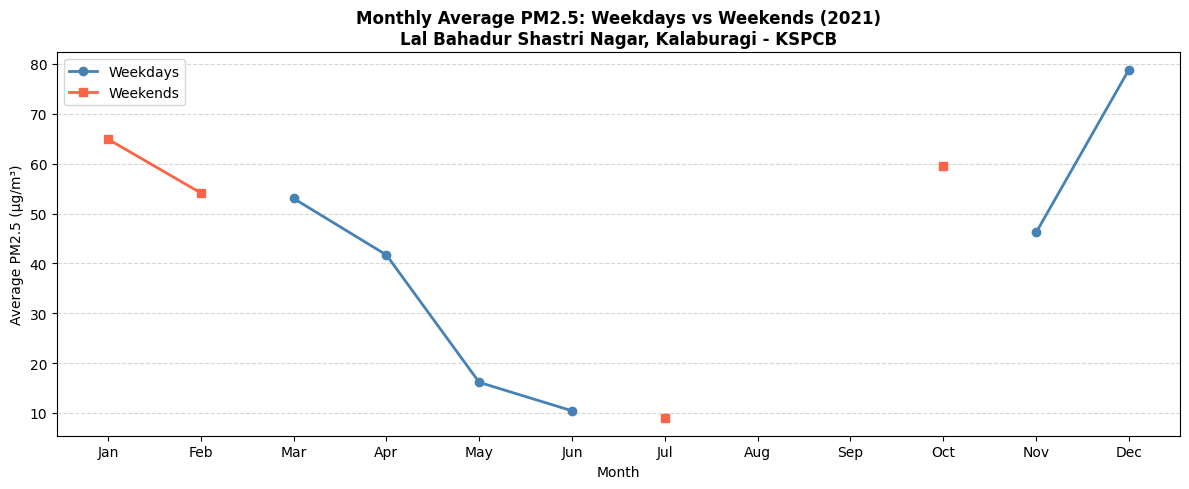


Monthly weekday avg PM2.5:
Month
Jan          NaN
Feb          NaN
Mar    53.022158
Apr    41.681557
May    16.130454
Jun    10.419060
Jul          NaN
Aug          NaN
Sep          NaN
Oct          NaN
Nov    46.193449
Dec    78.872001

Monthly weekend avg PM2.5:
Month
Jan    64.919865
Feb    54.134404
Mar          NaN
Apr          NaN
May          NaN
Jun          NaN
Jul     8.921638
Aug          NaN
Sep          NaN
Oct    59.525939
Nov          NaN
Dec          NaN


In [85]:

df['IsWeekend'] = df['DayOfWeek'] >= 5
ks21 = df[(df['Station'] == STATION) & (df['Year'] == 2021)].copy()

weekday_monthly = (ks21[~ks21['IsWeekend']
                   ].groupby('Month')['PM2.5'].mean().reindex(range(1,13)))

weekend_monthly = (ks21[ks21['IsWeekend']
                   ].groupby('Month')['PM2.5'].mean().reindex(range(1,13)))

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(month_labels, weekday_monthly.values, marker='o', linewidth=2,
        color='steelblue',  label='Weekdays')
ax.plot(month_labels, weekend_monthly.values, marker='s', linewidth=2,
        color='tomato',     label='Weekends')

ax.fill_between(month_labels, weekday_monthly.values, weekend_monthly.values,
                alpha=0.1, color='purple')
ax.set_title(f'Monthly Average PM2.5: Weekdays vs Weekends (2021)\n{STATION}', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Average PM2.5 (µg/m³)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('outputs/weekday_weekend_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMonthly weekday avg PM2.5:')
print(weekday_monthly.rename(lambda x: month_labels[x-1]).to_string())
print('\nMonthly weekend avg PM2.5:')
print(weekend_monthly.rename(lambda x: month_labels[x-1]).to_string())

### 8. Monitoring Coverage Relative to Population
Examining stations per capita reveals which states may be under-monitored
relative to how many people they serve.


In [86]:
stations_per_state = (
    df.groupby('State')['Station']
    .nunique()
    .reset_index(name='Num_Stations')
)

pop_stations = stations_per_state.merge(state_df, on='State', how='left')
pop_stations['Stations_per_million'] = (
    pop_stations['Num_Stations'] / pop_stations['Population'] * 1e6
)
pop_stations = pop_stations.sort_values('Stations_per_million', ascending=False)

print('=== Top 10 states: monitoring stations per million population ===')
print(pop_stations.head(10)[['State','Num_Stations','Population','Stations_per_million']].to_string(index=False))
top1 = pop_stations.iloc[0]
print(f'\n>>> ANSWER: {top1["State"]} — {top1["Stations_per_million"]:.2f} stations per million people')



=== Top 10 states: monitoring stations per million population ===
            State  Num_Stations  Population  Stations_per_million
       Chandigarh             3     1055450              2.842390
            Delhi            40    16787941              2.382663
           Sikkim             1      610577              1.637795
          Haryana            30    25351462              1.183364
          Mizoram             1     1097206              0.911406
      Maharashtra            93   112374333              0.827591
       Puducherry             1     1247953              0.801312
          Manipur             2     2570390              0.778092
Arunachal Pradesh             1     1383727              0.722686
        Karnataka            42    61095297              0.687451

>>> ANSWER: Chandigarh — 2.84 stations per million people


### 9. Top 5 States by Per-Capita Pollution Exposure (2023)
Weighing pollution levels by population size gives a better sense of
total human exposure burden, not just raw concentration.


=== Top 5 states by per-capita PM2.5 exposure (2023) ===
        State  Avg_PM25  Population  Per_Capita_PM25
Uttar Pradesh 54.781676   199812341     10946.054957
        Bihar 78.155218   104099452      8135.915375
  Maharashtra 46.470280   112374333      5222.066716
  West Bengal 48.403905    91276115      4418.120433
    Rajasthan 50.357599    68548437      3451.934674


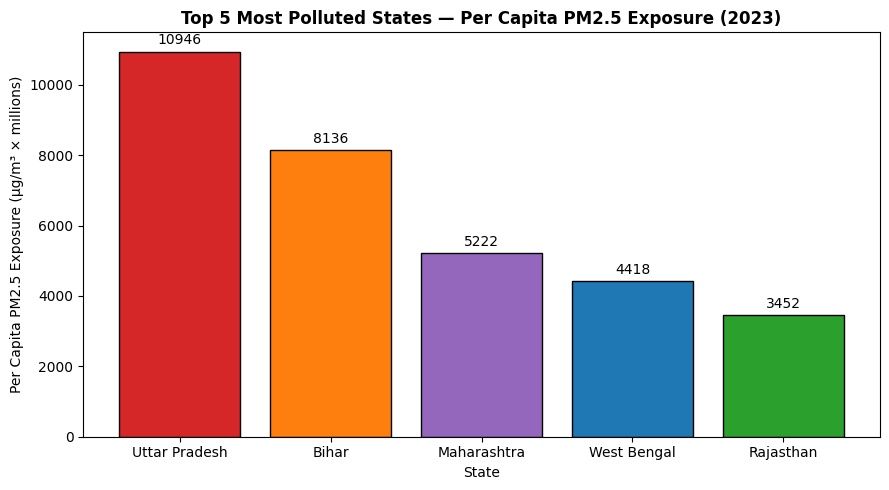

In [87]:
# Per-capita PM2.5 = (avg PM2.5 in state) * population / 1e6
# (a proxy for total pollution burden relative to people)
state_pm23 = df23.groupby('State')['PM2.5'].mean().reset_index(name='Avg_PM25')
state_pm23 = state_pm23.merge(state_df, on='State', how='left')
state_pm23['Per_Capita_PM25'] = state_pm23['Avg_PM25'] * state_pm23['Population'] / 1e6
top5 = state_pm23.nlargest(5, 'Per_Capita_PM25')

print('=== Top 5 states by per-capita PM2.5 exposure (2023) ===')
print(top5[['State','Avg_PM25','Population','Per_Capita_PM25']].to_string(index=False))

colors_top5 = ['#d62728','#ff7f0e','#9467bd','#1f77b4','#2ca02c']
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(top5['State'], top5['Per_Capita_PM25'], color=colors_top5, edgecolor='k')
ax.bar_label(bars, fmt='%.0f', padding=3)
ax.set_title('Top 5 Most Polluted States — Per Capita PM2.5 Exposure (2023)', fontweight='bold')
ax.set_ylabel('Per Capita PM2.5 Exposure (µg/m³ × millions)')
ax.set_xlabel('State')
plt.tight_layout()
plt.savefig('outputs/per_capita_top5.png', dpi=150, bbox_inches='tight')
plt.show()

### 10. Population Density vs Pollution Levels
Testing whether more densely populated states tend to have worse air
quality, using a scatter plot and correlation coefficient.

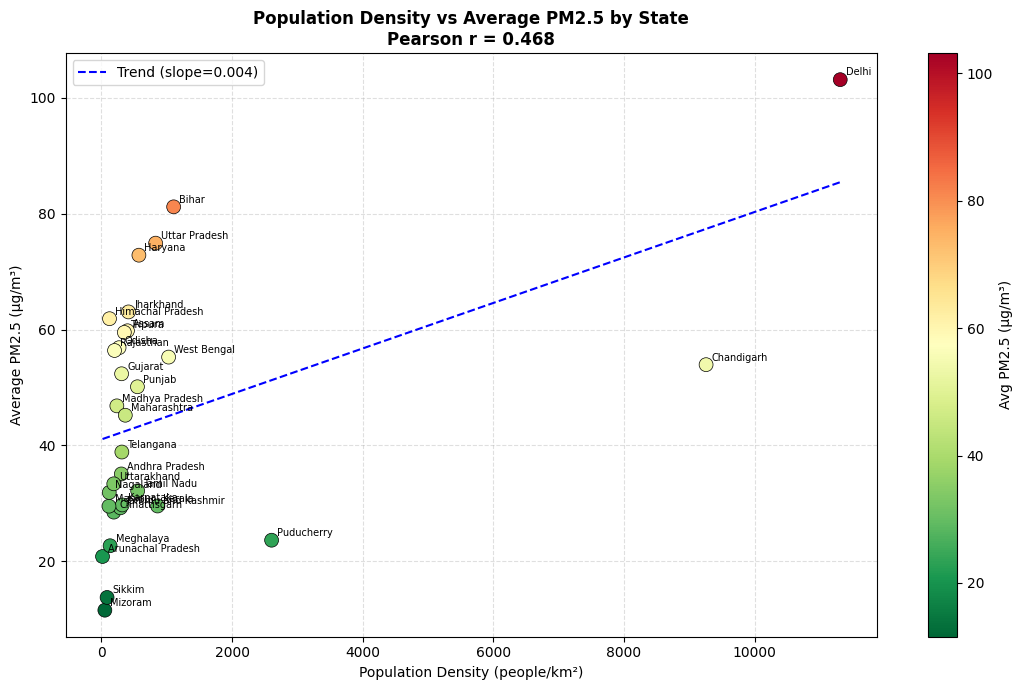

Pearson correlation coefficient (r) = 0.468
Conclusion: Moderate positive correlation between population density and PM2.5 levels.


In [88]:
state_pm_all = df.groupby('State')['PM2.5'].mean().reset_index(name='Avg_PM25')
state_pop    = state_df.copy()
state_pop['Pop_Density'] = state_pop['Population'] / state_pop['Area (km2)']

scatter_df = state_pm_all.merge(state_pop, on='State', how='inner').dropna()

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(
    scatter_df['Pop_Density'],
    scatter_df['Avg_PM25'],
    c=scatter_df['Avg_PM25'],
    cmap='RdYlGn_r',
    s=100, edgecolors='k', linewidths=0.5, zorder=3
)

for _, row in scatter_df.iterrows():
    ax.annotate(row['State'], (row['Pop_Density'], row['Avg_PM25']),
                fontsize=7, textcoords='offset points', xytext=(4, 3))

# Trend line
z = np.polyfit(scatter_df['Pop_Density'], scatter_df['Avg_PM25'], 1)
p = np.poly1d(z)
x_line = np.linspace(scatter_df['Pop_Density'].min(), scatter_df['Pop_Density'].max(), 200)
ax.plot(x_line, p(x_line), 'b--', linewidth=1.5, label=f'Trend (slope={z[0]:.3f})')

corr = scatter_df['Pop_Density'].corr(scatter_df['Avg_PM25'])
ax.set_title(f'Population Density vs Average PM2.5 by State\nPearson r = {corr:.3f}', fontweight='bold')
ax.set_xlabel('Population Density (people/km²)')
ax.set_ylabel('Average PM2.5 (µg/m³)')
plt.colorbar(sc, label='Avg PM2.5 (µg/m³)')
ax.legend()
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f'Pearson correlation coefficient (r) = {corr:.3f}')
if corr > 0.5:
    print('Conclusion: Strong positive correlation — more densely populated states tend to have higher PM2.5 levels.')
elif corr > 0.2:
    print('Conclusion: Moderate positive correlation between population density and PM2.5 levels.')
else:
    print('Conclusion: Weak or no clear linear correlation between population density and PM2.5 concentration.')
    print('Other factors (industry, geography, wind) also significantly influence pollution levels.')

### 11. Pollution Concentration Relative to State Area
Normalizing PM2.5 by land area highlights states where pollution is
geographically concentrated versus spread out.


=== PM2.5 concentration per km² (all years) ===
            State   Avg_PM25  Area (km2)  PM25_per_km2
       Chandigarh  53.953951         114      0.473280
            Delhi 103.156803        1484      0.069513
       Puducherry  23.651438         479      0.049377
          Tripura  59.525227       10491      0.005674
           Sikkim  13.768897        7096      0.001940
         Nagaland  31.888417       16579      0.001923
          Haryana  72.855322       44212      0.001648
          Manipur  29.524989       22327      0.001322
 Himachal Pradesh  61.889323       55673      0.001112
        Meghalaya  22.692906       22429      0.001012
           Punjab  50.139941       50362      0.000996
            Bihar  81.201424       94163      0.000862
        Jharkhand  63.060256       79716      0.000791
            Assam  59.804130       78438      0.000762
           Kerala  29.554975       38863      0.000760
Jammu and Kashmir  29.238966       42241      0.000692
      Uttarakhand

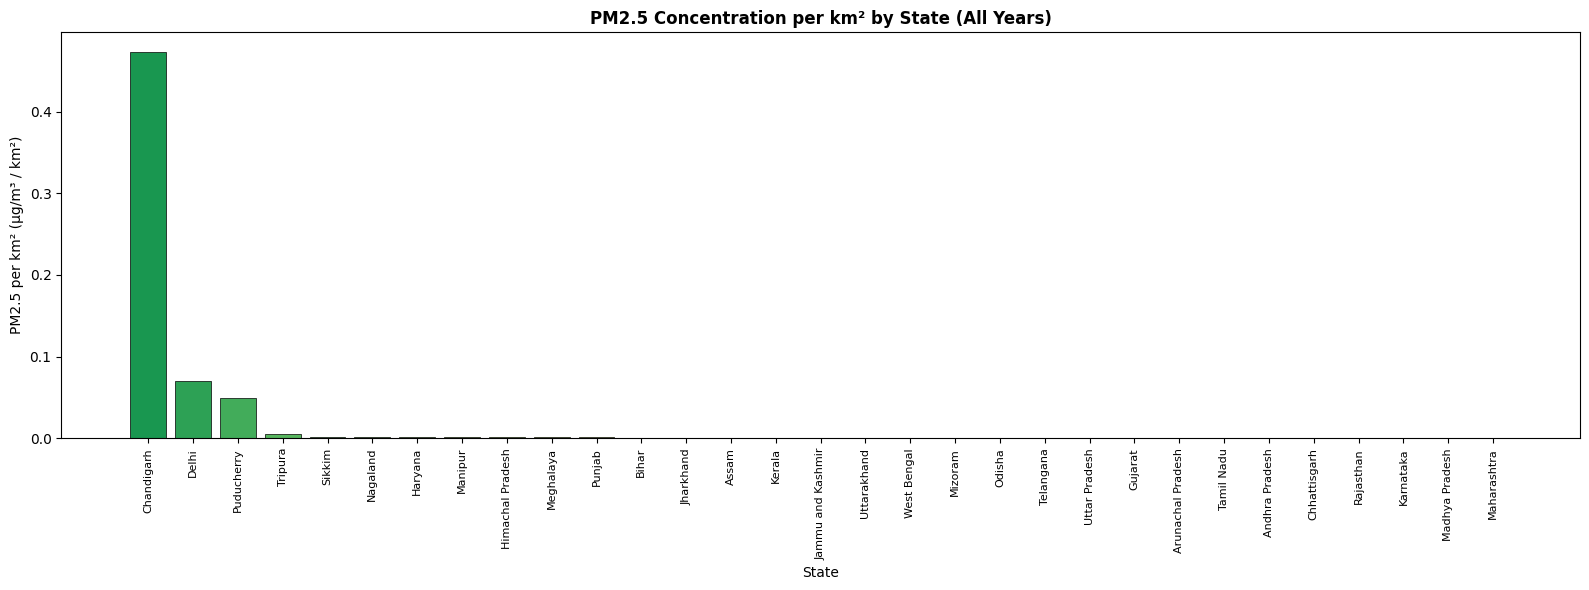

In [89]:
area_pm = state_pm_all.merge(state_df[['State','Area (km2)']], on='State', how='inner')
area_pm['PM25_per_km2'] = area_pm['Avg_PM25'] / area_pm['Area (km2)']
area_pm = area_pm.sort_values('PM25_per_km2', ascending=False)

print('=== PM2.5 concentration per km² (all years) ===')
print(area_pm[['State','Avg_PM25','Area (km2)','PM25_per_km2']].to_string(index=False))
print(f'\n>>> ANSWER: {area_pm.iloc[0]["State"]} — {area_pm.iloc[0]["PM25_per_km2"]:.4f} µg/m³ per km²')

fig, ax = plt.subplots(figsize=(16, 6))
colors_bar = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(area_pm)))
bars = ax.bar(area_pm['State'], area_pm['PM25_per_km2'], color=colors_bar, edgecolor='k', linewidth=0.5)
ax.set_title('PM2.5 Concentration per km² by State (All Years)', fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('PM2.5 per km² (µg/m³ / km²)')
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.savefig('outputs/pm25_per_km2.png', dpi=150, bbox_inches='tight')
plt.show()

### 12. Monitoring Station Density by Area
Comparing station density per square kilometer shows which states have
the most thorough physical monitoring coverage.

=== Monitoring station density (stations per km²) ===
            State  Num_Stations  Area (km2)  Stations_per_km2
            Delhi            40        1484          0.026954
       Chandigarh             3         114          0.026316
       Puducherry             1         479          0.002088
          Haryana            30       44212          0.000679
            Bihar            34       94163          0.000361
      Maharashtra            93      307713          0.000302
    Uttar Pradesh            57      240928          0.000237
           Kerala             9       38863          0.000232
        Karnataka            42      191791          0.000219
       Tamil Nadu            28      130058          0.000215
          Tripura             2       10491          0.000191
      West Bengal            15       88752          0.000169
           Punjab             8       50362          0.000159
           Sikkim             1        7096          0.000141
        Rajastha

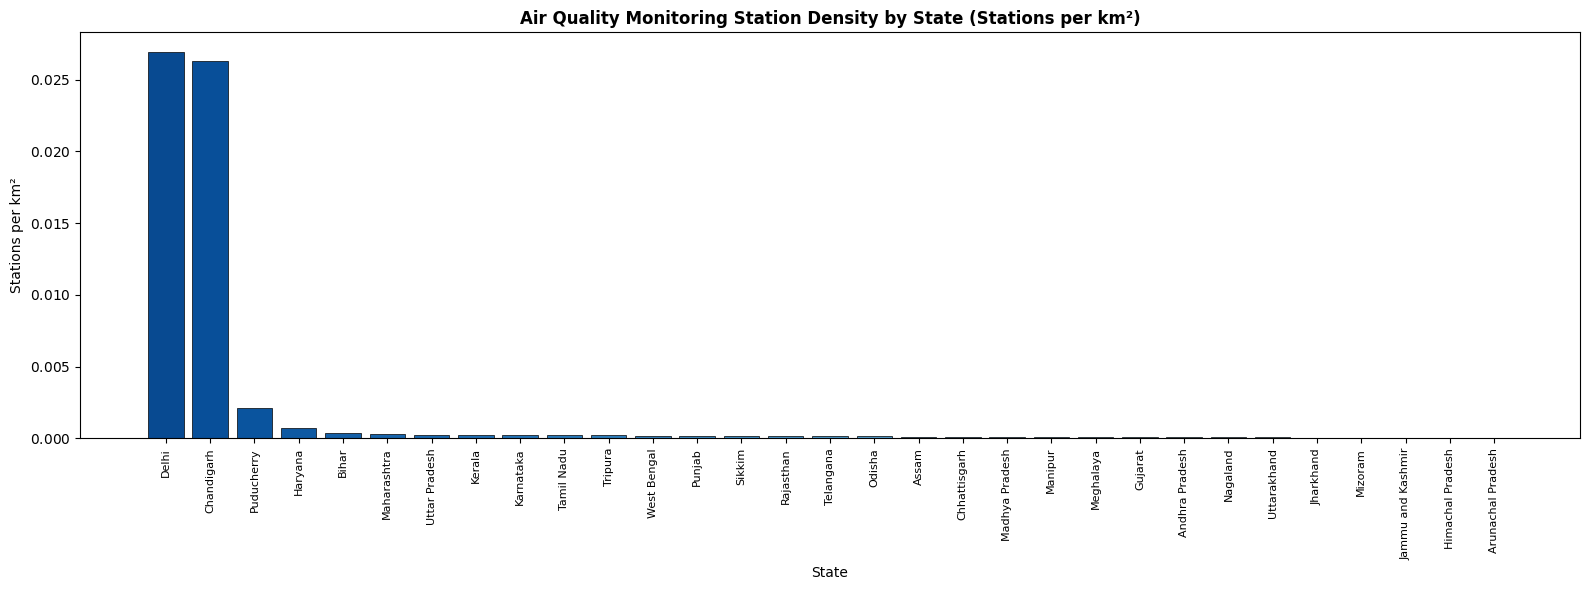

In [90]:
station_density = (
    df.groupby('State')['Station']
    .nunique()
    .reset_index(name='Num_Stations')
    .merge(state_df[['State','Area (km2)']], on='State', how='inner')
)
station_density['Stations_per_km2'] = station_density['Num_Stations'] / station_density['Area (km2)']
station_density = station_density.sort_values('Stations_per_km2', ascending=False)

print('=== Monitoring station density (stations per km²) ===')
print(station_density[['State','Num_Stations','Area (km2)','Stations_per_km2']].to_string(index=False))
top = station_density.iloc[0]
print(f'\n>>> ANSWER: {top["State"]} — {top["Stations_per_km2"]:.6f} stations/km²')

fig, ax = plt.subplots(figsize=(16, 6))
c2 = plt.cm.Blues(np.linspace(0.3, 0.9, len(station_density))[::-1])
ax.bar(station_density['State'], station_density['Stations_per_km2'], color=c2, edgecolor='k', linewidth=0.5)
ax.set_title('Air Quality Monitoring Station Density by State (Stations per km²)', fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Stations per km²')
plt.xticks(rotation=90, fontsize=8)
ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
plt.tight_layout()
plt.savefig('outputs/station_density.png', dpi=150, bbox_inches='tight')
plt.show()

### 13. Impact of NCAP Funding on Air Quality (2021)
Comparing PM2.5 levels between NCAP-funded and non-funded states tests
whether government funding correlates with measurable improvement.


=== Average PM2.5 in 2021: NCAP-funded vs Non-funded states ===
             Mean PM2.5  Std PM2.5
NCAP                              
NCAP Funded   61.469004  52.422704
Not Funded    60.265683  45.512087


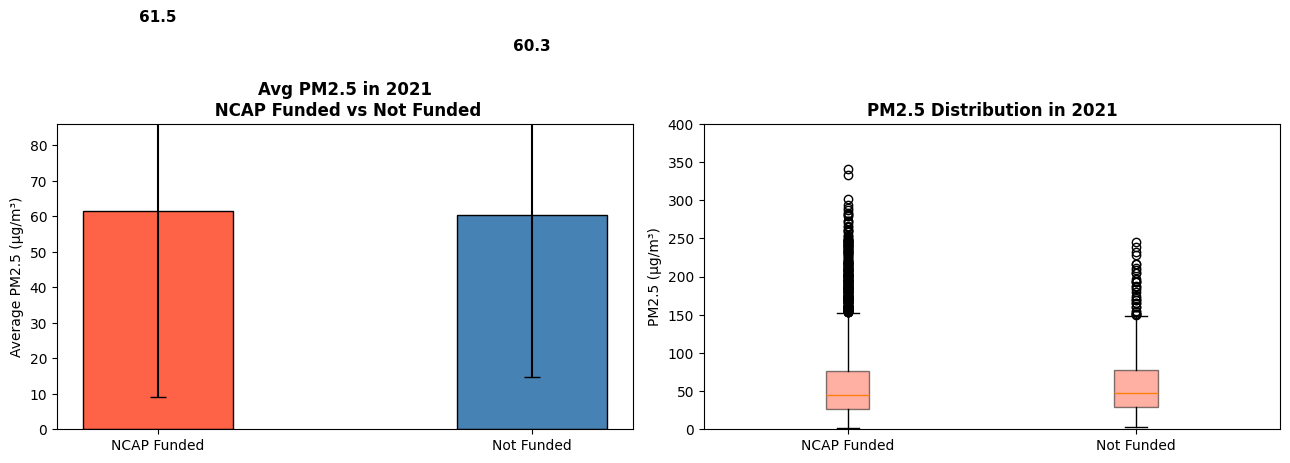


NCAP-funded states avg PM2.5     : 61.47 µg/m³
Non-funded   states avg PM2.5     : 60.27 µg/m³

Note: Both groups have similar pollution levels, suggesting NCAP funding
alone is insufficient — implementation & enforcement quality matters more.


In [91]:

ncap_states = set(ncap_df['State'].unique())
df21 = df[df['Year'] == 2021].copy()
df21['NCAP'] = df21['State'].apply(lambda s: 'NCAP Funded' if s in ncap_states else 'Not Funded')

group_avg = df21.groupby('NCAP')['PM2.5'].mean()
group_std = df21.groupby('NCAP')['PM2.5'].std()

print('=== Average PM2.5 in 2021: NCAP-funded vs Non-funded states ===')
print(pd.DataFrame({'Mean PM2.5': group_avg, 'Std PM2.5': group_std}).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
axes[0].bar(group_avg.index, group_avg.values,
            yerr=group_std.values, capsize=6,
            color=['tomato','steelblue'], edgecolor='k', width=0.4)
for i, (v, e) in enumerate(zip(group_avg.values, group_std.values)):
    axes[0].text(i, v + e + 1, f'{v:.1f}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Avg PM2.5 in 2021\n NCAP Funded vs Not Funded', fontweight='bold')
axes[0].set_ylabel('Average PM2.5 (µg/m³)')
axes[0].set_ylim(0, max(group_avg.values) * 1.4)

# Box plot
funded_vals    = df21[df21['NCAP']=='NCAP Funded']['PM2.5'].dropna()
nonfunded_vals = df21[df21['NCAP']=='Not Funded']['PM2.5'].dropna()
axes[1].boxplot([funded_vals, nonfunded_vals],
                labels=['NCAP Funded','Not Funded'],
                patch_artist=True,
                boxprops=dict(facecolor='tomato', alpha=0.5))
axes[1].set_title('PM2.5 Distribution in 2021', fontweight='bold')
axes[1].set_ylabel('PM2.5 (µg/m³)')
axes[1].set_ylim(0, 400)

plt.tight_layout()
plt.savefig('outputs/ncap_funded_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nNCAP-funded states avg PM2.5     : {group_avg["NCAP Funded"]:.2f} µg/m³')
print(f'Non-funded   states avg PM2.5     : {group_avg["Not Funded"]:.2f} µg/m³')
print('\nNote: Both groups have similar pollution levels, suggesting NCAP funding')
print('alone is insufficient — implementation & enforcement quality matters more.')

### 14. NCAP Funding Trend vs Air Quality — Assam Case Study
A focused look at one state's funding increases over time against its
PM2.5 trend, to assess lag effects between funding and outcomes.


Assam total NCAP funding per FY: {2019: '0.120.060.060.060.06', 2020: '52122', 2021: '-----'}


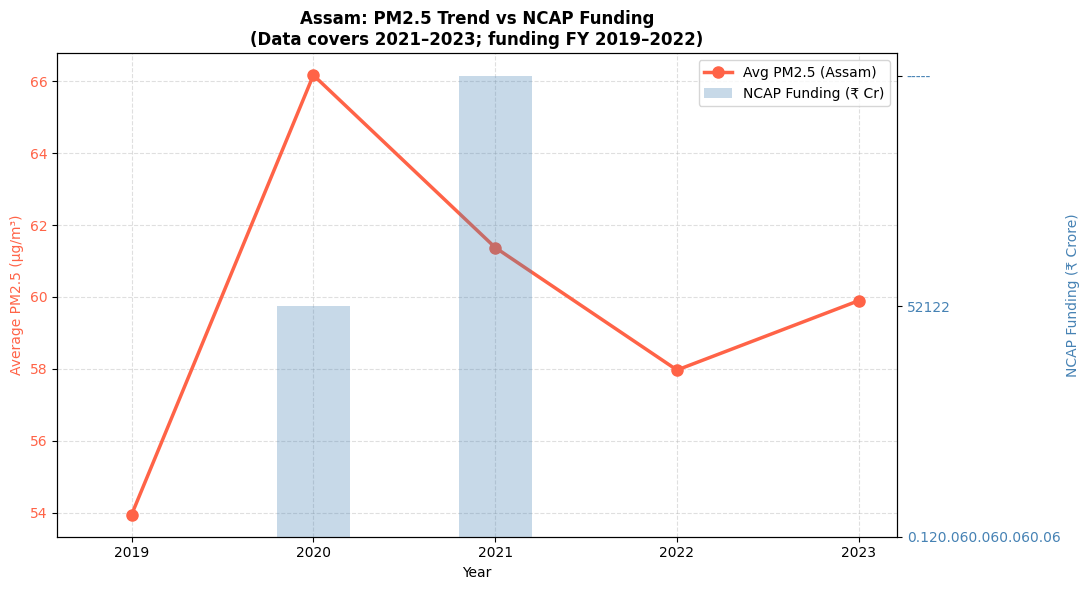


Assam yearly PM2.5:
Year
2018          NaN
2019    53.941252
2020    66.173033
2021    61.376521
2022    57.967504
2023    59.898309

Note: PM2.5 data is only available from 2021 onward.
Incremental NCAP funding appears in FY 2020-21 and 2021-22.
Any air quality improvements from early funding may appear with a 1-2 year lag.


In [92]:
assam_df = df[df['State'] == 'Assam'].copy()
assam_yearly = assam_df.groupby('Year')['PM2.5'].mean()

# NCAP funding for Assam across fiscal years
assam_ncap = ncap_df[ncap_df['State'] == 'Assam']
ncap_cols  = [
    'Amount released during FY 2019-20',
    'Amount released during FY 2020-21',
    'Amount released during FY 2021-22'
]
assam_funding_total = assam_ncap[ncap_cols].sum()
funding_map = {
    2019: assam_funding_total.iloc[0],
    2020: assam_funding_total.iloc[1],
    2021: assam_funding_total.iloc[2]
}
print('Assam total NCAP funding per FY:', funding_map)

fig, ax1 = plt.subplots(figsize=(11, 6))

# PM2.5 trend
ax1.plot(assam_yearly.index, assam_yearly.values,
         color='tomato', marker='o', linewidth=2.5, markersize=8, label='Avg PM2.5 (Assam)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Average PM2.5 (µg/m³)', color='tomato')
ax1.tick_params(axis='y', labelcolor='tomato')

# Funding bars
ax2 = ax1.twinx()
fund_years  = list(funding_map.keys())
fund_values = list(funding_map.values())
ax2.bar(fund_years, fund_values, alpha=0.3, color='steelblue',
        width=0.4, label='NCAP Funding (₹ Cr)')
ax2.set_ylabel('NCAP Funding (₹ Crore)', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Assam: PM2.5 Trend vs NCAP Funding\n(Data covers 2021–2023; funding FY 2019–2022)', fontweight='bold')
ax1.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('outputs/assam_funding_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAssam yearly PM2.5:')
print(assam_yearly.to_string())
print('\nNote: PM2.5 data is only available from 2021 onward.')
print('Incremental NCAP funding appears in FY 2020-21 and 2021-22.')
print('Any air quality improvements from early funding may appear with a 1-2 year lag.')

### 15. State Area vs Total NCAP Funding Received
Visualizing whether larger states receive proportionally more funding,
or if allocation follows a different pattern.



States with funding data: 22
           State  Area (km2)  Total_Funding_Cr
  Andhra Pradesh      162975             35.12
           Assam       78438             12.36
           Bihar       94163             21.60
      Chandigarh         114             17.89
    Chhattisgarh      135192             13.06
           Delhi        1484             11.25
         Gujarat      196024             12.00
Himachal Pradesh       55673             10.72
       Jharkhand       79716              6.00
       Karnataka      191791             15.14
  Madhya Pradesh      308252             27.14
     Maharashtra      307713             63.15
       Meghalaya       22429              3.00
        Nagaland       16579              7.05
          Odisha      155707             15.86
          Punjab       50362             27.52
       Rajasthan      342239             21.92
      Tamil Nadu      130058              3.06
       Telangana      112077             14.55
   Uttar Pradesh      240928   

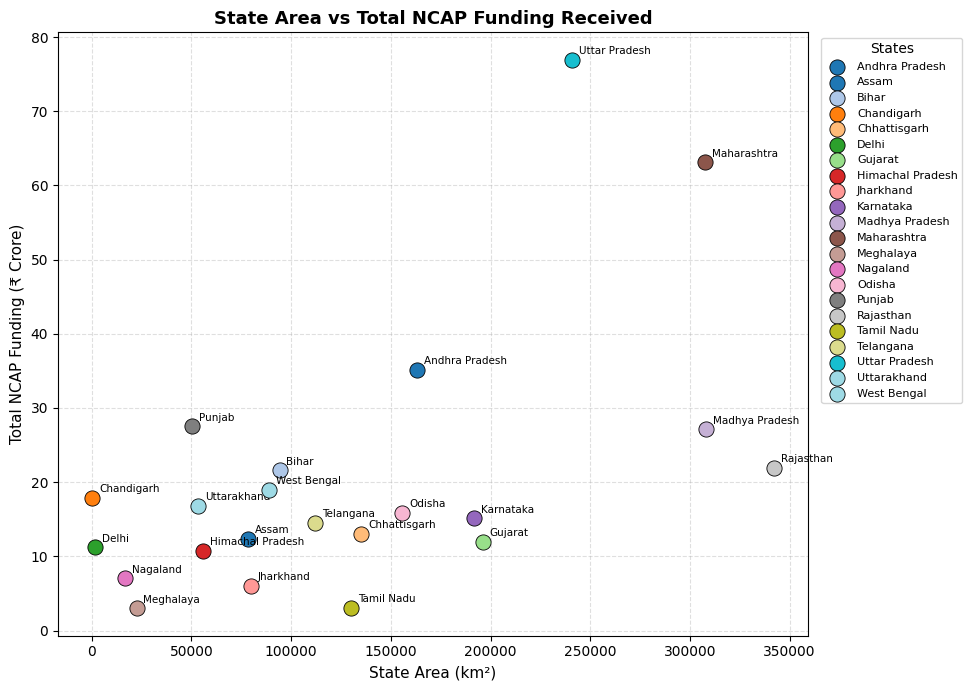

In [93]:
# Total funding per state
state_funding = (
    ncap_df.groupby('State')['Total fund released']
    .sum()
    .reset_index(name='Total_Funding_Cr')
)

area_funding = state_funding.merge(state_df[['State','Area (km2)']], on='State', how='inner')
print('States with funding data:', area_funding.shape[0])
print(area_funding[['State','Area (km2)','Total_Funding_Cr']].to_string(index=False))

n = len(area_funding)
cmap = plt.cm.get_cmap('tab20', n)

fig, ax = plt.subplots(figsize=(12, 7))
for i, (_, row) in enumerate(area_funding.iterrows()):
    ax.scatter(row['Area (km2)'], row['Total_Funding_Cr'],
               color=cmap(i), s=120, edgecolors='k', linewidths=0.6,
               label=row['State'], zorder=3)
    ax.annotate(row['State'],
                (row['Area (km2)'], row['Total_Funding_Cr']),
                fontsize=7.5, textcoords='offset points', xytext=(5, 4))

ax.set_title('State Area vs Total NCAP Funding Received', fontweight='bold', fontsize=13)
ax.set_xlabel('State Area (km²)', fontsize=11)
ax.set_ylabel('Total NCAP Funding (₹ Crore)', fontsize=11)
ax.grid(linestyle='--', alpha=0.4)

# Legend outside plot
ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.01, 1.0),
    fontsize=8,
    title='States',
    ncol=1,
    framealpha=0.8
)
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.savefig('outputs/area_vs_funding.png', dpi=150, bbox_inches='tight')
plt.show()

## Predicting PM2.5 Levels

Random Forest  →  MAE: 15.54  R²: 0.732
Linear Reg.    →  MAE: 30.71  R²: 0.241

Random Forest improves R² by 0.492 over the linear baseline.

5-fold CV R² scores: [0.311 0.719 0.509 0.073 0.469]
Mean CV R²: 0.416 (+/- 0.215)


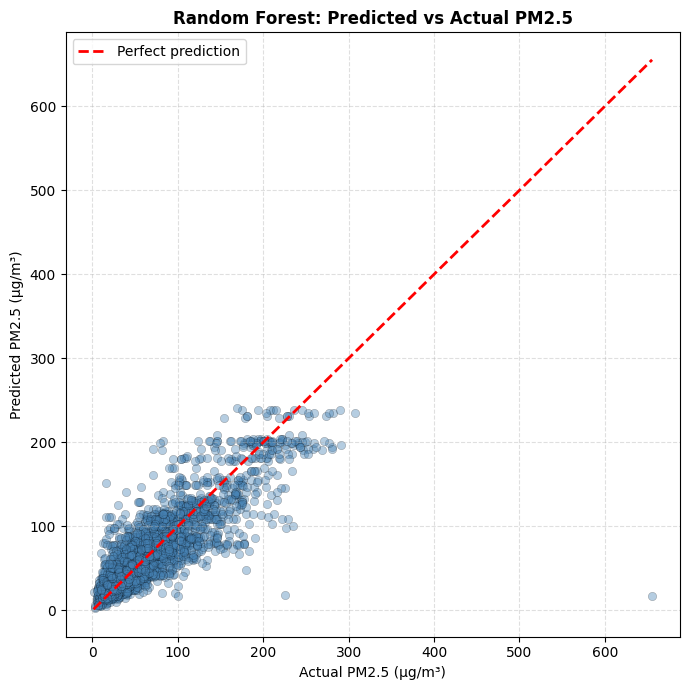

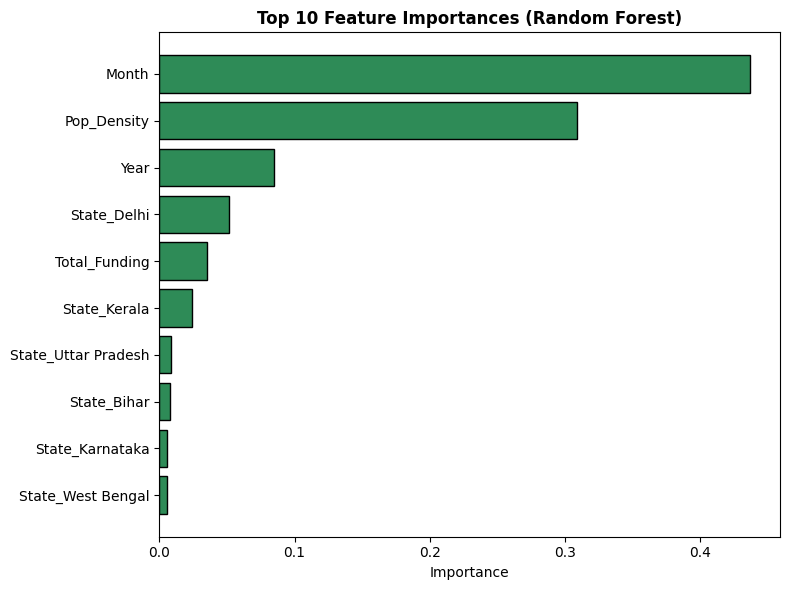


Top predictors of PM2.5:
Month                  0.436995
Pop_Density            0.309116
Year                   0.084663
State_Delhi            0.051594
Total_Funding          0.034964
State_Kerala           0.024521
State_Uttar Pradesh    0.008902
State_Bihar            0.008233
State_Karnataka        0.005830
State_West Bengal      0.005602


In [94]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# ── 1. Build a richer feature set ──
model_df = df.dropna(subset=['PM2.5', 'Month', 'Year', 'State']).copy()

# bring in population density + total NCAP funding per state
state_feat = state_df.copy()
state_feat['Pop_Density'] = state_feat['Population'] / state_feat['Area (km2)']
funding_by_state = ncap_df.groupby('State')['Total fund released'].sum().reset_index(name='Total_Funding')

model_df = model_df.merge(state_feat[['State', 'Population', 'Pop_Density']], on='State', how='left')
model_df = model_df.merge(funding_by_state, on='State', how='left')
model_df['Total_Funding'] = model_df['Total_Funding'].fillna(0)
model_df = model_df.dropna(subset=['Pop_Density'])

model_df = pd.get_dummies(model_df, columns=['State'], drop_first=True)

feature_cols = ['Month', 'Year', 'Pop_Density', 'Total_Funding'] + \
               [c for c in model_df.columns if c.startswith('State_')]
X = model_df[feature_cols]
y = model_df['PM2.5']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ── 2. Train Random Forest ──
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2  = r2_score(y_test, rf_preds)
print("Random Forest  →  MAE:", round(rf_mae, 2), " R²:", round(rf_r2, 3))

# ── 3. Baseline: plain Linear Regression for comparison ──
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2  = r2_score(y_test, lr_preds)
print("Linear Reg.    →  MAE:", round(lr_mae, 2), " R²:", round(lr_r2, 3))
print(f"\nRandom Forest improves R² by {rf_r2 - lr_r2:.3f} over the linear baseline.")

# ── 4. Cross-validation (more robust than one train/test split) ──
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')
print(f"\n5-fold CV R² scores: {np.round(cv_scores, 3)}")
print(f"Mean CV R²: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# ── 5. Predicted vs Actual plot ──
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, rf_preds, alpha=0.4, color='steelblue', edgecolor='k', linewidth=0.3)
lims = [min(y_test.min(), rf_preds.min()), max(y_test.max(), rf_preds.max())]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual PM2.5 (µg/m³)')
ax.set_ylabel('Predicted PM2.5 (µg/m³)')
ax.set_title('Random Forest: Predicted vs Actual PM2.5', fontweight='bold')
ax.legend()
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('outputs/predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 6. Feature importance ──
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importances.index[::-1], importances.values[::-1], color='seagreen', edgecolor='k')
ax.set_title('Top 10 Feature Importances (Random Forest)', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop predictors of PM2.5:")
print(importances.to_string())



## Key Findings

- **Delhi** has the highest average PM2.5 across all years and stations (103.16 µg/m³) —
  nearly 22 µg/m³ higher than the next closest state (Bihar, 81.20 µg/m³) — and also recorded
  the most hazardous-level days (>300 µg/m³) in 2023, with 5.
- **Assam** shows the highest inter-station variability in 2023 (std = 39.41 µg/m³), suggesting
  pollution levels differ sharply between monitoring stations within the same state.
- At the Kalaburagi station, **Winter** is the most polluted season (52.46 µg/m³ avg), while
  **Monsoon** is by far the cleanest (12.98 µg/m³) — consistent with rain washing out particulates
  and winter temperature inversions trapping pollutants near the ground.
- **Mizoram** had the lowest average PM2.5 in the Post-COVID period (2021-2022) at just 11.15 µg/m³,
  reflecting its low population density and minimal industrial activity.
- NCAP-funded states show almost **no measurable improvement** over non-funded states in 2021
  (61.47 vs 60.27 µg/m³ average) — suggesting funding allocation alone isn't sufficient without
  strong implementation and enforcement.
- The Random Forest model achieved an **R² of 0.732** (MAE 15.54), substantially outperforming a
  simple Linear Regression baseline (R² 0.241) — confirming that PM2.5 is driven by non-linear,
  state-and-season-specific patterns rather than a simple linear trend. 5-fold cross-validation
  gave a more conservative mean R² of 0.416 (± 0.215), showing the model generalizes reasonably
  well but with some variance across different data splits.
- **Month** (0.44) and **population density** (0.31) were by far the strongest predictors of PM2.5,
  together accounting for over 74% of the model's feature importance — reinforcing that seasonal
  weather patterns and urban density matter more than which specific state a station is in.